# NLP

>Imports

In [1]:
import pandas as pd
import numpy as np
import regex as re
from nltk import download
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
import pickle

>funciones

In [2]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub("https?|www", " ", text)
    text = re.sub(r'[^a-z ]', " ", text)
    text = re.sub(r'\s+', " ", text)
    return text.split()

In [3]:
download("wordnet")
lemmatizer = WordNetLemmatizer()

download("stopwords")
stop_words = stopwords.words("english")

def lemmatize_text(words, lemmatizer=lemmatizer):
    tokens = [lemmatizer.lemmatize(word) for word in words]
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [word for word in tokens if len(word) > 2]
    return tokens

[nltk_data] Downloading package wordnet to /home/vscode/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /home/vscode/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Carga y análisis de datos 

In [4]:
df = pd.read_csv('../data/raw/url_spam.csv')
df

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True
...,...,...
2994,https://www.smartcitiesworld.net/news/news/dee...,False
2995,https://www.youtube.com/watch,True
2996,https://techcrunch.com/2019/07/04/an-optimisti...,False
2997,https://www.technologyreview.com/2019/12/20/13...,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   url      2999 non-null   object
 1   is_spam  2999 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 26.5+ KB


>Vemos que los datos estan repartidos en 2999 filas y dos columnas de objects que son las URL y bool que son los valores True y False correspondientes a si es spam o no

In [6]:
df.nunique()

url        2369
is_spam       2
dtype: int64

>Vemos también que tenemos solo 2369 urls únicas por lo que tendremos que eliminar duplicados y lógicamente solo dos posibles valores booleanos de True o False

In [7]:
df = df.drop_duplicates()
df = df.reset_index(inplace = False, drop = True)
df.shape

(2369, 2)

>Eliminamos los duplicados y reiniciamos los indices para no ver saltos entre estos de más de uno y vemos que como deciamos anteriormente quedan solo 2369 filas únicas

In [8]:
spam_or_not = {
    'Spam' : len(df.loc[df['is_spam'] == 1]),
    'No_spam' : len(df.loc[df['is_spam'] == 0])
}
spam_or_not

{'Spam': 244, 'No_spam': 2125}

>Vemos también que hay 244 enlaces con spam y 2125 que no tienen

## Procesado del texto

>Primero pasaremos la columna resultado de si es spam o no de un booleano a un valor numérico, los False a 0 y los True a 1

In [9]:
df['is_spam'] = df['is_spam'].astype(int)
df

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,1
1,https://www.hvper.com/,1
2,https://briefingday.com/m/v4n3i4f3,1
3,https://briefingday.com/n/20200618/m#commentform,0
4,https://briefingday.com/fan,1
...,...,...
2364,https://www.theverge.com/2020/6/29/21306889/di...,0
2365,https://www.smartcitiesworld.net/news/news/dee...,0
2366,https://techcrunch.com/2019/07/04/an-optimisti...,0
2367,https://www.technologyreview.com/2019/12/20/13...,0


>Procesamos el tecto de los url con regex y la función preprocess_text() anteriormente generada que elimina los http, https, www, todo lo que no sean letras y después devuelve el texto spliteado, es decir, como una lista de textos separados.

In [10]:
df["url"] = df["url"].apply(preprocess_text)
df

,url,is_spam
0,"[briefingday, us, list, manage, com, unsubscribe]",1
1,"[hvper, com]",1
2,"[briefingday, com, m, v, n, i, f]",1
3,"[briefingday, com, n, m, commentform]",0
4,"[briefingday, com, fan]",1
...,...,...
2364,"[theverge, com, disney, deepfake, face, swappi...",0
2365,"[smartcitiesworld, net, news, news, deepfake, ...",0
2366,"[techcrunch, com, an, optimistic, view, of, de...",0
2367,"[technologyreview, com, this, startup, claims,...",0


>Ahora que tenemos el texto en este formato eliminaremos las stopwords, las palabras demasiado pequeñas o letras sueltas y lematizaremos los textos para acabar de procesarlo y poder utilizarlo en nuestro modelo. Este proceso se hará mediante una función generada anteriormente llamada lemmatize_text() 

In [11]:
df["url"] = df["url"].apply(lemmatize_text)
df

,url,is_spam
0,"[briefingday, list, manage, com, unsubscribe]",1
1,"[hvper, com]",1
2,"[briefingday, com]",1
3,"[briefingday, com, commentform]",0
4,"[briefingday, com, fan]",1
...,...,...
2364,"[theverge, com, disney, deepfake, face, swappi...",0
2365,"[smartcitiesworld, net, news, news, deepfake, ...",0
2366,"[techcrunch, com, optimistic, view, deepfakes]",0
2367,"[technologyreview, com, startup, claim, deepfa...",0


>Para visualizar de manera sencilla quan habituales son las palabras utilizaremos un wordcloud (nube de palabras)

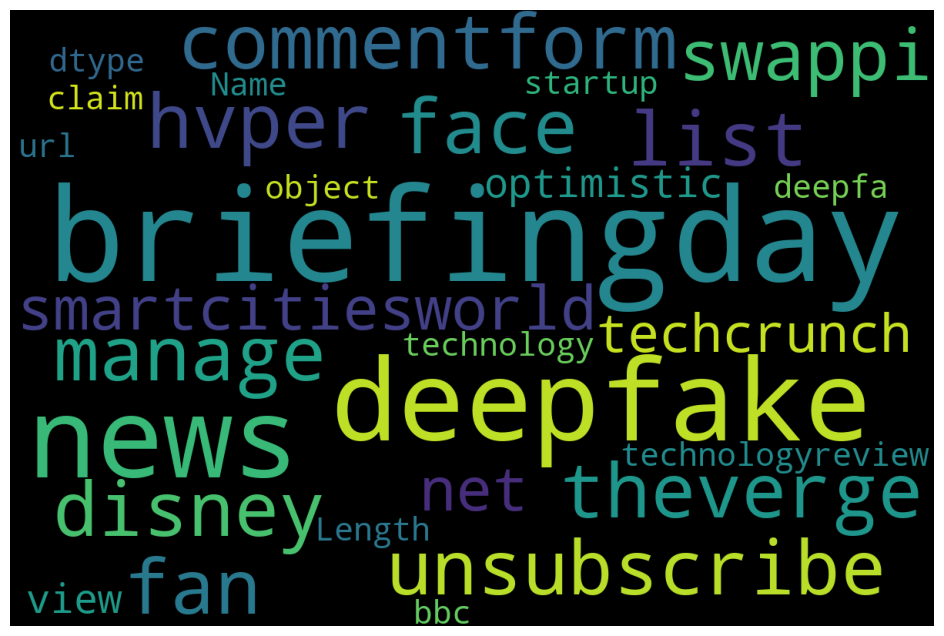

In [12]:
wordcloud = WordCloud(width=1200,
                      height=800,
                      background_color="black",
                      max_words=1000,
                      min_font_size=20,
                      random_state=18).generate(str(df["url"]))

fig = plt.figure(figsize=(12, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

>Finalmente, antes de modelar, tenemos que pasar las palabras a números para que el modelo pueda trabajar con ellas, haremos una matriz que muestre por cada palabra una columna y una fila por cada url que tenemos, además de separar la variable objetivo de las predictoras.

In [13]:
word_list = df["url"]
word_list = [" ".join(tokens) for tokens in word_list]

vectorizer = TfidfVectorizer(max_features=5000,
                             max_df=0.8,
                             min_df=5)

X = vectorizer.fit_transform(word_list).toarray()
y = df["is_spam"]
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(2369, 612))

## Modelado

>Antes de empezar con el modelo tenemos que hacer un split de los datos que tenemos trabajados ya

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=25)

>Ahora instanciamos el modelo y lo entrenamos

In [15]:
model = SVC(kernel="linear",
            random_state=25)
model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


>Generamos la predicción

In [16]:
y_pred = model.predict(X_test)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

>Mostramos su métrica de accuracy

In [17]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9345991561181435

>Mostramos una clasificación de los resultados estadísticos

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96       425
           1       0.85      0.45      0.59        49

    accuracy                           0.93       474
   macro avg       0.89      0.72      0.78       474
weighted avg       0.93      0.93      0.93       474



>Mostramos la matriz de confusión


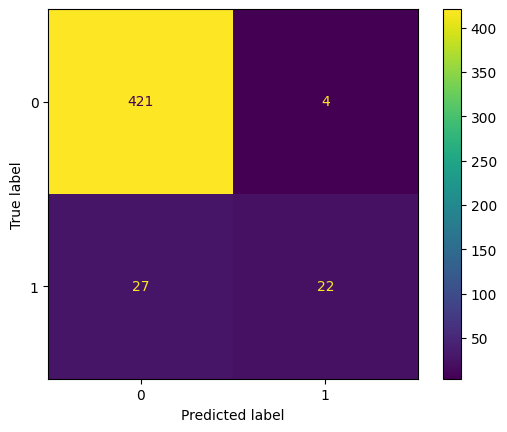

In [19]:
confusion = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion).plot()
plt.show()

## Optimización del modelo

>Generamos las opciones de hiperparametros

In [20]:
hyperparams = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]
}

>Instanciamos y entrenamos la optimización del modelo

In [21]:
grid = GridSearchCV(model, hyperparams, scoring = "accuracy", cv = 10)

In [22]:
grid.fit(X_train, y_train)
grid.best_params_

{'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}

>Generamos la métrica accuracy de la optimización y la mostramos junto a la original

In [23]:
best = grid.best_estimator_
y_pred_best = best.predict(X_test)
grid_accuracy = accuracy_score(y_test, y_pred_best)
accuracy, grid_accuracy

(0.9345991561181435, 0.9345991561181435)

>Mostramos sus resultados probabilísticos

In [24]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96       425
           1       0.85      0.45      0.59        49

    accuracy                           0.93       474
   macro avg       0.89      0.72      0.78       474
weighted avg       0.93      0.93      0.93       474



>Mostramos la matriz de confusión de la optimización

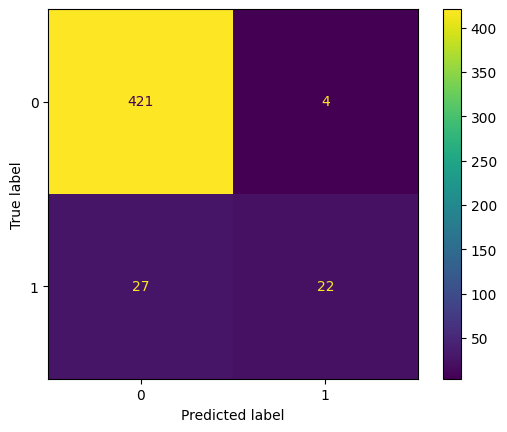

In [25]:
grid_confusion = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(grid_confusion).plot()
plt.show()

>Pese a la optimización del modelo, sus resultados y métricas son idénticos, por lo que en este caso la optimización no ha servido de mucho, nos podriamos haber quedado con el modelo original. Además este ya tenía unos muy buenos resultados con un accurracy superior al 0.93.

## Guardado del modelo

In [26]:
with open('../models/nlp-model.pkl', 'wb') as file:
    pickle.dump(model, file)     

with open('../models/nlp-grid.pkl', 'wb') as file:
    pickle.dump(best, file)